# Principal Component Analysis

---
[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/davidrajm/DSA-DL-FDP/blob/main/Day%2002%20-%20Machine%20Learning%20-%20Dr%20Arun%20RajKumar/Lab%20Sessions/06_PCA.ipynb)


In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

from sklearn.decomposition       import PCA
from sklearn.preprocessing       import StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score, confusion_matrix
from sklearn.model_selection import train_test_split

from sklearn.datasets import make_classification
from sklearn.utils import Bunch

plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['font.size'] = 12
sns.set_theme(style='whitegrid')

print("All libraries imported successfully.")

def compute_metrics(y_true, y_pred, label):
    """Return a dict of regression metrics for a given set of predictions."""
    mae  = mean_absolute_error(y_true, y_pred)
    mse  = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)
    r2   = r2_score(y_true, y_pred)
    return {'Set': label, 'MAE': mae, 'MSE': mse, 'RMSE': rmse, 'R2': r2}


All libraries imported successfully.


In [4]:
X_raw, y = make_classification(
    n_samples=500,
    n_features=10,
    n_informative=7,
    n_redundant=2,
    n_classes=3,
    n_clusters_per_class=1,
    random_state=42
)
feature_names = [f'feature_{i}' for i in range(X_raw.shape[1])]
dataset = Bunch(
    data=X_raw,
    target=y,
    feature_names=feature_names,
    DESCR="Synthetic 3-class classification dataset via make_classification"
)

In [5]:
df = pd.DataFrame(dataset.data, columns=dataset.feature_names)
df['target'] = dataset.target

X = df.drop(columns='target')
y = df['target']    

In [7]:
scaler    = StandardScaler()
X_scaled  = scaler.fit_transform(X)

In [8]:
# ── Train / Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y,
    test_size=0.2,
    random_state=42
)

In [13]:
pca = PCA(random_state=42)
pca.fit(X_train)                  # Fit on train only — avoids data leakage

X_train_pca = pca.transform(X_train)
X_test_pca  = pca.transform(X_test)


explained = pca.explained_variance_ratio_
print("Model trained on training set.")

Model trained on training set.


In [15]:
def plot_pca_results(
    pca,
    X_scaled,
    y,
    feature_names,
    class_meta=None,
    figsize=(17, 4),
):
    """
    Prints variance table and plots PCA results.

    Parameters
    ----------
    pca           : Fitted PCA object (full components)
    X_scaled      : Scaled feature matrix (all samples)
    y             : Target labels
    feature_names : List of feature names
    class_meta    : List of (label, name, color) tuples
                    Default: [(0,"Low","#C44E52"), (1,"Medium","#55A868"), (2,"High","#4C72B0")]
    figsize       : Figure size for the 3-panel plot  (default: (17, 4))
    """

    if class_meta is None:
        class_meta = [
            (0, "Low",    "#C44E52"),
            (1, "Medium", "#55A868"),
            (2, "High",   "#4C72B0"),
        ]

    explained = pca.explained_variance_ratio_

    # ── 1. Variance Table ─────────────────────────────────────────────────────
    print(f"\n  {'Component':<12} {'Variance Explained':>20} {'Cumulative':>12}")
    print(f"  {'-' * 46}")
    cum = 0
    for i, ev in enumerate(explained):
        cum += ev
        bar   = "█" * int(ev * 200)          # inline mini bar for quick scan
        print(f"  PC{i+1:<10} {ev*100:>18.2f}%  {cum*100:>10.2f}%  {bar}")

    # ── 2. Figure Setup ───────────────────────────────────────────────────────
    fig, axes = plt.subplots(1, 3, figsize=figsize)
    fig.suptitle("PCA — Principal Component Analysis", fontsize=13, fontweight="bold")

    # ── 3. Scree Plot ─────────────────────────────────────────────────────────
    n = len(explained)
    cumvar = np.cumsum(explained) * 100

    axes[0].bar(range(1, n + 1), explained * 100, color="#4C72B0", edgecolor="white", label="Individual")
    axes[0].plot(range(1, n + 1), cumvar, "r-o", lw=2, label="Cumulative")
    axes[0].axhline(95, color="green", linestyle="--", lw=1.5, label="95% threshold")

    # Annotate the elbow — first PC where cumulative >= 95%
    elbow = next((i + 1 for i, c in enumerate(cumvar) if c >= 95), n)
    axes[0].axvline(elbow, color="orange", linestyle=":", lw=1.5, label=f"Elbow @ PC{elbow}")

    axes[0].set_xlabel("Principal Component")
    axes[0].set_ylabel("Variance Explained (%)")
    axes[0].set_title("Scree Plot")
    axes[0].set_xticks(range(1, n + 1))
    axes[0].legend(fontsize=8)

    # ── 4. 2D Scatter ─────────────────────────────────────────────────────────
    pca2       = PCA(n_components=2, random_state=42)
    X_pca2     = pca2.fit_transform(X_scaled)
    exp2       = pca2.explained_variance_ratio_

    for label, name, color in class_meta:
        mask = y == label
        axes[1].scatter(
            X_pca2[mask, 0], X_pca2[mask, 1],
            label=name, color=color,
            alpha=0.6, edgecolors="white", s=50
        )

    axes[1].set_xlabel(f"PC1 ({exp2[0]*100:.1f}% var)")
    axes[1].set_ylabel(f"PC2 ({exp2[1]*100:.1f}% var)")
    axes[1].set_title(f"2D PCA — {' / '.join(m[1] for m in class_meta)}")
    axes[1].legend(fontsize=8)

    # ── 5. Biplot ─────────────────────────────────────────────────────────────
    loading = pca2.components_.T
    scale   = 3                               # arrow scale factor

    for i, feat in enumerate(feature_names):
        dx, dy = loading[i, 0] * scale, loading[i, 1] * scale
        axes[2].arrow(
            0, 0, dx, dy,
            head_width=0.1, head_length=0.05,
            fc="#8172B2", ec="#8172B2"
        )
        axes[2].text(dx * 1.1, dy * 1.1, feat, fontsize=9, ha="center")

    axes[2].set_xlim(-4, 4)
    axes[2].set_ylim(-4, 4)
    axes[2].axhline(0, color="black", lw=0.5)
    axes[2].axvline(0, color="black", lw=0.5)
    axes[2].set_title("PCA Loading Vectors (Biplot)")
    axes[2].set_xlabel("PC1")
    axes[2].set_ylabel("PC2")

    plt.tight_layout()
    plt.show()


  Component      Variance Explained   Cumulative
  ----------------------------------------------
  PC1                       28.86%       28.86%  █████████████████████████████████████████████████████████
  PC2                       21.23%       50.08%  ██████████████████████████████████████████
  PC3                       11.84%       61.93%  ███████████████████████
  PC4                       10.78%       72.71%  █████████████████████
  PC5                        9.48%       82.19%  ██████████████████
  PC6                        8.46%       90.65%  ████████████████
  PC7                        5.76%       96.41%  ███████████
  PC8                        3.59%      100.00%  ███████
  PC9                        0.00%      100.00%  
  PC10                       0.00%      100.00%  


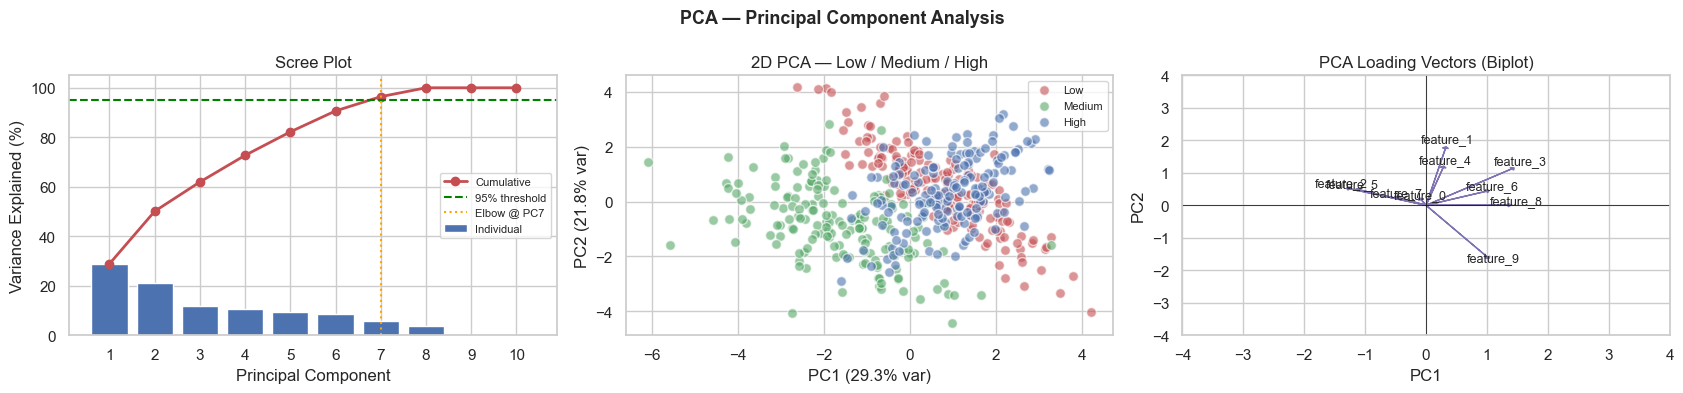

In [16]:
plot_pca_results(
    pca=pca,
    X_scaled=X_scaled,
    y=y,
    feature_names=feature_names,
)